# Loading API Keys

In [ ]:
import langchain
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI_API")
os.environ["GROQ_API_KEY"]= os.getenv("GORQ_API")


### Loading gemini model and chatting with it.

In [ ]:
from langchain.chat_models import init_chat_model

my_model = init_chat_model(
    model="gemini-3.1-flash-lite",
    model_provider="google_genai"
)

response = my_model.invoke("Hi who are you?")
print(response)

In [8]:
response2 = my_model.invoke("What you think about future of developer job since ai growing like carazy?")
print(response2)

content=[{'type': 'text', 'text': 'The common narrative—*“AI will replace all developers”*—is a bit like saying *“calculators replaced all mathematicians.”* It’s not that the job is disappearing; it’s that the **definition of the job** is undergoing the biggest shift since the invention of the compiler.\n\nHere is an honest breakdown of how the future of software development is likely to play out:\n\n### 1. The Death of "Code Typing," the Rise of "System Architecture"\nIn the past, a huge portion of a developer’s time was spent on syntax, boilerplate, and searching Stack Overflow for how to implement a basic API. AI is taking over the "typing" part.\n*   **The Shift:** We are moving from being "builders" (laying bricks) to being "architects" (designing the building).\n*   **The Result:** Juniors will have a harder time getting their foot in the door because the "busy work" they used to do is now done by AI. However, seniors will become 10x more productive because they can generate func

### Load Groq model

In [ ]:
from langchain.chat_models import init_chat_model

my_model = init_chat_model(
    model="openai/gpt-oss-120b",
    model_provider="groq"
)




In [15]:
# Using the groq and getting a response
response3 = my_model.invoke("who are you?")
print(response3)

content='I’m ChatGPT, a large language model created by OpenAI. I’m designed to understand and generate text in response to a wide variety of prompts. My training involved processing vast amounts of publicly available text up through September\u202f2021 (with a later knowledge update in 2024), which helps me answer questions, offer explanations, brainstorm ideas, and more. I don’t have personal experiences or consciousness—I generate responses based on patterns in the data I was trained on. If you’d like to know anything specific or need help with something, just let me know!' additional_kwargs={'reasoning_content': 'The user asks "who are you?" Should respond as ChatGPT, mention being a large language model trained by OpenAI, with knowledge cutoff and date. Follow guidelines.'} response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 75, 'total_tokens': 233, 'completion_time': 0.341116446, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.015

## Creating first agent
#### An agent is nothing but an llm connected to a tool

In [8]:
from langchain.agents import create_agent
import requests


# This bottom function is a sample one to show how a tool look like
# def get_weather(location):
#     """ This is a function that takes location
#         and return the weather of that location
#     """
#     return f"The weather in {location} is sunny and 25 degrees Celsius"



def get_weather(location):
    """Get the current weather for a location."""

    # Step 1: Find the location's latitude and longitude
    geo_url = "https://geocoding-api.open-meteo.com/v1/search"

    geo_params = {
        "name": location,
        "count": 1
    }

    geo_response = requests.get(geo_url, params=geo_params, timeout=10)
    geo_response.raise_for_status()
    geo_data = geo_response.json()

    # Check whether the location exists
    if not geo_data.get("results"):
        return f"Location '{location}' not found."

    place = geo_data["results"][0]

    latitude = place["latitude"]
    longitude = place["longitude"]
    place_name = place["name"]

    # Step 2: Get current weather using the coordinates
    weather_url = "https://api.open-meteo.com/v1/forecast"

    weather_params = {
        "latitude": latitude,
        "longitude": longitude,
        "current": "temperature_2m,relative_humidity_2m,apparent_temperature,wind_speed_10m"
    }

    weather_response = requests.get(
        weather_url,
        params=weather_params,
        timeout=10
    )
    weather_response.raise_for_status()
    weather_data = weather_response.json()

    # Step 3: Extract the weather information
    current = weather_data["current"]

    temperature = current["temperature_2m"]
    humidity = current["relative_humidity_2m"]
    feels_like = current["apparent_temperature"]
    wind_speed = current["wind_speed_10m"]

    # Step 4: Return the result
    return (
        f"Current weather in {place_name}:\n"
        f"Temperature: {temperature}°C\n"
        f"Feels like: {feels_like}°C\n"
        f"Humidity: {humidity}%\n"
        f"Wind speed: {wind_speed} km/h"
    )


In [9]:
agent = create_agent(
    model = "google_genai:gemini-3.1-flash-lite",
    tools = [get_weather],
    system_prompt="You are a helpful assistant that can provide weather information for any location"
)

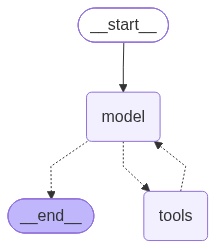

In [4]:
agent

In [10]:
response = agent.invoke({"messages":[{"role":"user", "content":"what is the weather in Kannur today?"}]})

In [11]:
response

{'messages': [HumanMessage(content='what is the weather in Kannur today?', additional_kwargs={}, response_metadata={}, id='a5cd1cbf-1014-476a-a650-0cb72b0a7e72'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Kannur, India"}'}, '__gemini_function_call_thought_signatures__': {'call_426777': 'EnMKcQFpFH0TrOrqzym9m7QsVKOAk4gCBxU0Vr6ZPZ1tSMnJbIvRW30q7/9RFW7iSo6mU7gG62Hpr+U8Cwnl2Ovsj87NsrRQkXYhaF4JjuF2q1t8jtN5xTiyCOzvAfEjE7+zfzIWF3Z99q7umt1gPuW4R5Hh'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a11f15-a29b-7273-89a0-7eec0fbccdc5-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Kannur, India'}, 'id': 'call_426777', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 19, 'total_tokens': 87, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='Cu